# s07 — Del Moran Scatterplot al Local Moran: ¿dónde está el patrón?
## CM0866 · Clase 7 · EAFIT 2026

---

| Parte | Contenido | Dataset | Tiempo |
|---|---|---|---|
| **A** | De la clasificación descriptiva al Local Moran · Iᵢ = zᵢ × Wzᵢ | Ciclistas | 20 min |
| **B** | Prueba permutacional local · pᵢ · mapa LISA | Ciclistas + Brexit | 35 min |
| **C** | Moran Global vs. LISA: ¿qué agrega el local? | Ciclistas + Brexit | 15 min |
| **D** | Datos propios del equipo | Proyecto de cada equipo | 35 min |

> *En la clase 6 aprendimos a clasificar cada zona por cuadrante — eso era descriptivo.*
> *Hoy preguntamos: ¿qué tan fuerte es la asociación de cada zona con su entorno?*
> *¿Y es estadísticamente significativa?*

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 0 — Librerías y datos
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from libpysal.weights import KNN
from libpysal import weights
import esda
import splot.esda as esda_plot
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.family':'sans-serif','figure.facecolor':'white'})
os.makedirs('outputs', exist_ok=True)
np.random.seed(42)

ciclistas = gpd.read_file('../datos/morfologia/Ospina_cyclists_origins_4326_BD.zip').to_crs('EPSG:32618')
for v in ['length_km', 'o_cbd', 'stratum']:
    ciclistas[v] = pd.to_numeric(ciclistas[v], errors='coerce')
w_cic = KNN.from_dataframe(ciclistas, k=5)
w_cic.transform = 'r'

ref  = pd.read_csv('../Clase_05/data/brexit_vote.csv')
lads = gpd.read_file('../Clase_05/data/local_authority_districts.geojson')
db   = lads.merge(
    ref[['Area_Code','Pct_Leave','Pct_Remain','Pct_Turnout']],
    left_on='lad16cd', right_on='Area_Code'
).to_crs(epsg=3857).dropna(subset=['Pct_Leave'])
w_brex = KNN.from_dataframe(db, k=8)
w_brex.transform = 'R'

col_lisa = {1:'#2563EB', 2:'#16A34A', 3:'#DC2626', 4:'#F97316', 0:'#E2E8F0'}
nom_lisa  = {1:'HH (clúster alto)', 2:'LH (outlier)',
             3:'LL (clúster bajo)', 4:'HL (outlier)', 0:'No significativo'}
nombres_q = {1:'HH', 2:'LH', 3:'LL', 4:'HL'}

print(f'Ciclistas: {len(ciclistas)} · Brexit: {len(db)} distritos ✓')

/home/jessi/Documents/doctorate/courses/202602_esda_spatial_econometrics/code/ESDA_code_git/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ciclistas: 810 · Brexit: 380 distritos ✓


---
## Parte A — Del cuadrante al Local Moran

En la clase 6 calculamos $z_i$ y $Wz_i$ y asignamos cuadrantes descriptivos.
Hoy damos el paso siguiente:

$$\boxed{I_i = z_i \times Wz_i}$$

Multiplicar las dos coordenadas del punto en el Moran Scatterplot.
Eso es el **Local Moran** — la aritmética que explica los cuadrantes:

- HH: $(+)(+) = +$ → $I_i > 0$  ·  LL: $(-)(-)= +$ → $I_i > 0$
- HL: $(+)(-) = -$ → $I_i < 0$  ·  LH: $(-)(+) = -$ → $I_i < 0$

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA A1 — Iᵢ manual: zᵢ × Wzᵢ para cada ciclista
# ─────────────────────────────────────────────────────────────────────────────
y_cic  = ciclistas['length_km'].values
z_cic  = (y_cic - y_cic.mean()) / y_cic.std()
Wz_cic = weights.lag_spatial(w_cic, z_cic)
Ii_manual = z_cic * Wz_cic

print('─── Iᵢ = zᵢ × Wzᵢ — primeros 5 ciclistas ──────────────────────────────')
print(f'  {"i":>4}  {"zᵢ":>8}  {"Wzᵢ":>8}  {"Iᵢ":>10}  cuadrante')
print('  ' + '─'*45)
for i in range(5):
    q = ('HH' if z_cic[i]>0 and Wz_cic[i]>0 else
         'LL' if z_cic[i]<0 and Wz_cic[i]<0 else
         'HL' if z_cic[i]>0 else 'LH')
    print(f'  {i:>4}  {z_cic[i]:>8.4f}  {Wz_cic[i]:>8.4f}  {Ii_manual[i]:>10.4f}  {q}')
print()
print(f'Iᵢ > 0 (similitud):  {(Ii_manual>0).sum()} ciclistas')
print(f'Iᵢ < 0 (disimilitud): {(Ii_manual<0).sum()} ciclistas')
print()
print('→ Iᵢ cuantifica la asociación. Pero todavía no sabemos si es azar.')

─── Iᵢ = zᵢ × Wzᵢ — primeros 5 ciclistas ──────────────────────────────
     i        zᵢ       Wzᵢ          Iᵢ  cuadrante
  ─────────────────────────────────────────────
     0    2.2142    1.7953      3.9752  HH
     1   -0.4071    0.1590     -0.0647  LH
     2    2.1814    1.2275      2.6777  HH
     3   -0.7896   -0.2139      0.1689  LL
     4   -1.1364   -0.1280      0.1454  LL

Iᵢ > 0 (similitud):  565 ciclistas
Iᵢ < 0 (disimilitud): 245 ciclistas

→ Iᵢ cuantifica la asociación. Pero todavía no sabemos si es azar.


---
## Parte B — Prueba permutacional local y mapa LISA

**¿Cómo funciona la prueba permutacional local?**

1. Tomar los 810 valores de `length_km`
2. Redistribuirlos al azar entre los 810 orígenes — la W no cambia
3. Calcular $I_i$ para cada ciclista con ese reparto aleatorio
4. Repetir 999 veces
5. $p_i$ = proporción de veces que el $I_i$ aleatorio supera al real

`esda.Moran_Local()` hace todo esto en una sola llamada.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA B1 — esda.Moran_Local(): Iᵢ + prueba permutacional + pᵢ
# ─────────────────────────────────────────────────────────────────────────────
ml_cic = esda.Moran_Local(y_cic, w_cic, permutations=999)

# Verificar: Iᵢ esda ≈ Iᵢ manual
print(f'Correlación Iᵢ_esda vs. Iᵢ_manual: {np.corrcoef(ml_cic.Is, Ii_manual)[0,1]:.6f}')
print('(≈ 1.0 — son la misma cosa con diferente normalización)')
print()

sig_mask = ml_cic.p_sim < 0.05
print('─── Resultados ──────────────────────────────────────────────────────────')
print(f'  Total: {len(ciclistas)}  ·  Significativos pᵢ<0.05: {sig_mask.sum()} ({sig_mask.mean()*100:.1f}%)')
print(f'  No significativos: {(~sig_mask).sum()} ({(~sig_mask).mean()*100:.1f}%)')
print()
print('─── Clústeres y outliers significativos ─────────────────────────────────')
for q, nombre in nombres_q.items():
    n = ((ml_cic.q==q) & sig_mask).sum()
    tipo = 'Clúster' if nombre in ['HH','LL'] else 'Outlier'
    print(f'  {nombre} ({tipo}): {n}')
print()
print(f'Clase 6: todos los 810 coloreados (descriptivo)')
print(f'Clase 7: solo {sig_mask.sum()} con pᵢ < 0.05 en el mapa LISA')

Correlación Iᵢ_esda vs. Iᵢ_manual: 1.000000
(≈ 1.0 — son la misma cosa con diferente normalización)

─── Resultados ──────────────────────────────────────────────────────────
  Total: 810  ·  Significativos pᵢ<0.05: 241 (29.8%)
  No significativos: 569 (70.2%)

─── Clústeres y outliers significativos ─────────────────────────────────
  HH (Clúster): 76
  LH (Outlier): 24
  LL (Clúster): 113
  HL (Outlier): 28

Clase 6: todos los 810 coloreados (descriptivo)
Clase 7: solo 241 con pᵢ < 0.05 en el mapa LISA


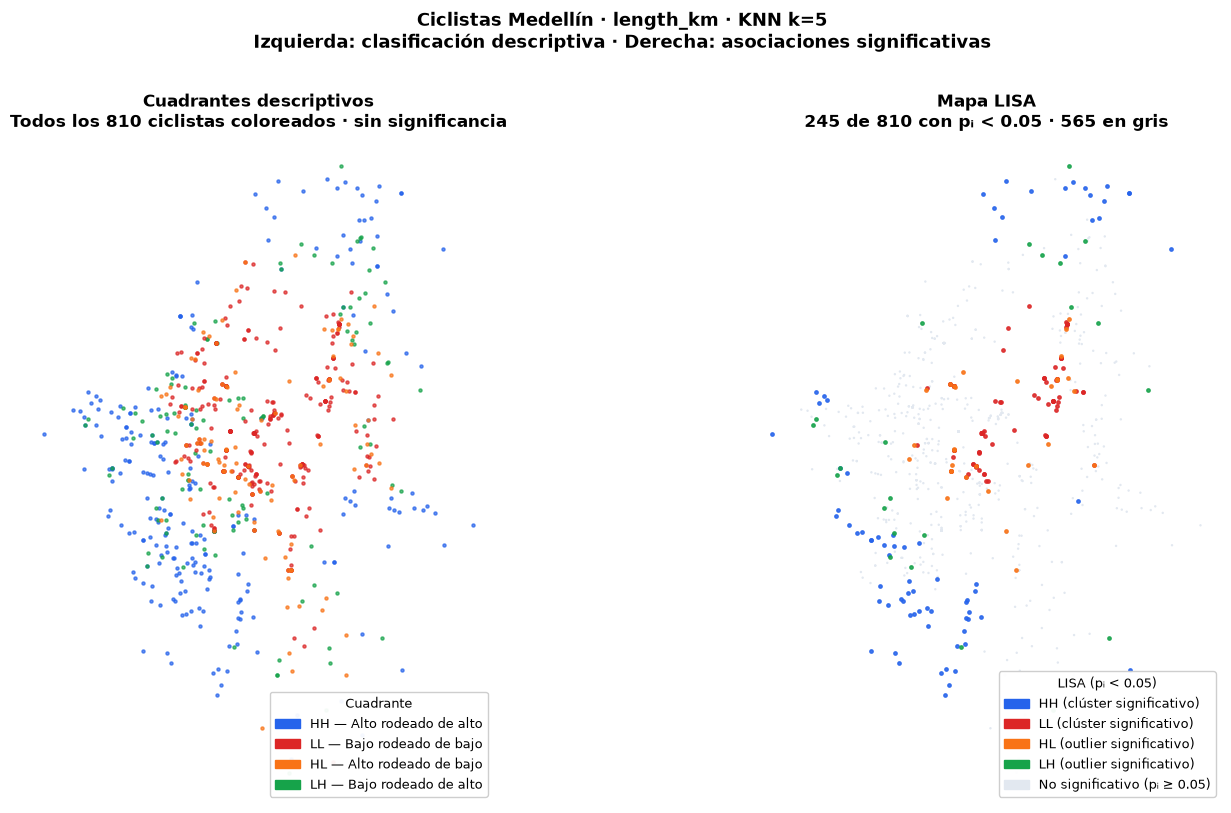

─── Ciclistas: descriptivo vs. LISA ─────────────────────────────────────
  Cuadrante  Descriptivo     LISA   Pasan a gris
  ────────────────────────────────────────────
  HH              250       75            175
  LL              315      117            198
  HL              116       30             86
  LH              129       23            106
  Total           810      245            565


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Cuadrantes descriptivos vs. LISA — Ciclistas Medellín
# ─────────────────────────────────────────────────────────────────────────────

y_cic  = ciclistas['length_km'].values
z_cic  = (y_cic - y_cic.mean()) / y_cic.std()
Wz_cic = weights.lag_spatial(w_cic, z_cic)

def cuadrante(zi, wzi):
    if   zi > 0 and wzi > 0: return 1   # HH
    elif zi < 0 and wzi < 0: return 3   # LL
    elif zi > 0 and wzi < 0: return 4   # HL
    else:                    return 2   # LH

ciclistas['cuad_desc'] = [cuadrante(z, wz) for z, wz in zip(z_cic, Wz_cic)]

ml_cic  = esda.Moran_Local(y_cic, w_cic, permutations=999)
sig_cic = ml_cic.p_sim < 0.05
ciclistas['lisa_sig'] = ml_cic.q * sig_cic.astype(int)

col      = {1:'#2563EB', 2:'#16A34A', 3:'#DC2626', 4:'#F97316'}
col_lisa = {1:'#2563EB', 2:'#16A34A', 3:'#DC2626', 4:'#F97316', 0:'#E2E8F0'}
nom_desc = {1:'HH — Alto rodeado de alto', 2:'LH — Bajo rodeado de alto',
            3:'LL — Bajo rodeado de bajo', 4:'HL — Alto rodeado de bajo'}
nom_lisa = {1:'HH (clúster significativo)', 2:'LH (outlier significativo)',
            3:'LL (clúster significativo)', 4:'HL (outlier significativo)',
            0:'No significativo (pᵢ ≥ 0.05)'}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Panel izquierdo: cuadrantes descriptivos ─────────────────────────────────
ax1 = axes[0]
for q, color in col.items():
    ciclistas[ciclistas['cuad_desc'] == q].plot(
        ax=ax1, color=color, markersize=5, alpha=0.7, zorder=2)
ax1.legend(handles=[mpatches.Patch(color=col[q], label=nom_desc[q])
                    for q in [1,3,4,2]],
           loc='lower right', fontsize=9,
           title='Cuadrante', title_fontsize=9, framealpha=0.95)
ax1.set_title(f'Cuadrantes descriptivos\n'
              f'Todos los {len(ciclistas)} ciclistas coloreados · sin significancia',
              fontsize=12, fontweight='bold')
ax1.set_axis_off()

# ── Panel derecho: mapa LISA ──────────────────────────────────────────────────
ax2 = axes[1]
ciclistas.plot(ax=ax2, color='#E2E8F0', markersize=3,
               edgecolor='none', zorder=1)
for q, color in col_lisa.items():
    if q == 0: continue
    mask = ciclistas['lisa_sig'] == q
    if mask.sum() > 0:
        ciclistas[mask].plot(ax=ax2, color=color,
                              markersize=6, alpha=0.85, zorder=3)
ax2.legend(handles=[mpatches.Patch(color=col_lisa[q], label=nom_lisa[q])
                    for q in [1,3,4,2,0]],
           loc='lower right', fontsize=9,
           title='LISA (pᵢ < 0.05)', title_fontsize=9, framealpha=0.95)
ax2.set_title(f'Mapa LISA\n'
              f'{sig_cic.sum()} de {len(ciclistas)} con pᵢ < 0.05 · '
              f'{len(ciclistas)-sig_cic.sum()} en gris',
              fontsize=12, fontweight='bold')
ax2.set_axis_off()

plt.suptitle('Ciclistas Medellín · length_km · KNN k=5\n'
             'Izquierda: clasificación descriptiva · Derecha: asociaciones significativas',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/s07_cic_desc_vs_lisa.png', dpi=150, bbox_inches='tight')
plt.show()

print('─── Ciclistas: descriptivo vs. LISA ─────────────────────────────────────')
print(f'  {"Cuadrante":<6} {"Descriptivo":>12} {"LISA":>8} {"Pasan a gris":>14}')
print('  ' + '─'*44)
for q, nombre in [(1,'HH'),(3,'LL'),(4,'HL'),(2,'LH')]:
    nd = (ciclistas['cuad_desc'] == q).sum()
    nl = (ciclistas['lisa_sig']  == q).sum()
    print(f'  {nombre:<6} {nd:>12} {nl:>8} {nd-nl:>14}')
print(f'  {"Total":<6} {len(ciclistas):>12} {sig_cic.sum():>8} '
      f'{len(ciclistas)-sig_cic.sum():>14}')

Brexit: 155 de 380 distritos significativos (pᵢ < 0.05)
  HH: 75
  LH: 6
  LL: 70
  HL: 4


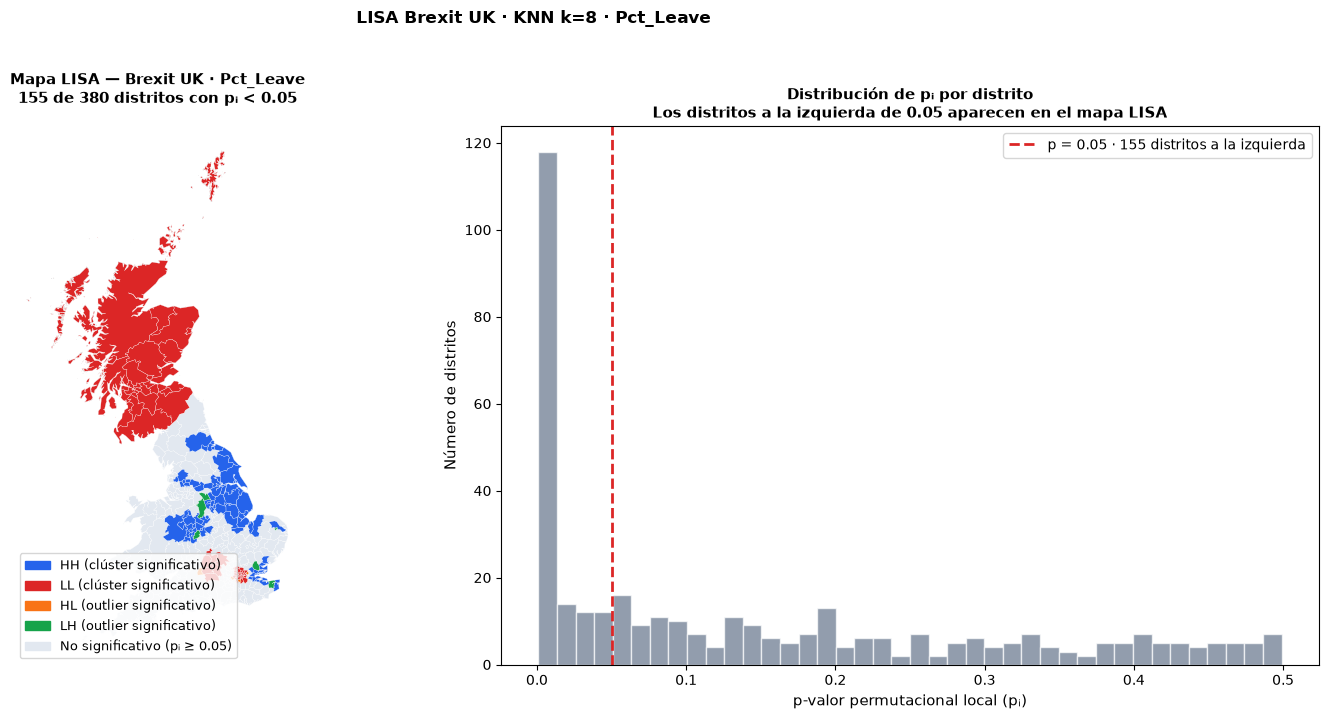

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA B3 — LISA Brexit: mapa + distribución de pᵢ
# ─────────────────────────────────────────────────────────────────────────────
y_brex  = db['Pct_Leave'].values
ml_brex = esda.Moran_Local(y_brex, w_brex, permutations=999)
sig_brex = ml_brex.p_sim < 0.05
db['lisa_sig'] = ml_brex.q * sig_brex.astype(int)

print(f'Brexit: {sig_brex.sum()} de {len(db)} distritos significativos (pᵢ < 0.05)')
for q, nombre in nombres_q.items():
    n = ((ml_brex.q==q) & sig_brex).sum()
    print(f'  {nombre}: {n}')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax1 = axes[0]
db.plot(ax=ax1, color='#E2E8F0', edgecolor='white', linewidth=0.2, zorder=1)
for q, color in col_lisa.items():
    if q==0: continue
    mask = db['lisa_sig']==q
    if mask.sum()>0:
        db[mask].plot(ax=ax1, color=color, edgecolor='white', linewidth=0.2, zorder=3)
ax1.legend(handles=[mpatches.Patch(color=col_lisa[q],label=nom_lisa[q]) for q in [1,3,4,2,0]],
           loc='lower left', fontsize=9)
ax1.set_title(f'Mapa LISA — Brexit UK · Pct_Leave\n'
              f'{sig_brex.sum()} de {len(db)} distritos con pᵢ < 0.05',
              fontsize=11, fontweight='bold')
ax1.set_axis_off()

ax2 = axes[1]
ax2.hist(ml_brex.p_sim, bins=40, color='#64748B', alpha=0.7, edgecolor='white')
ax2.axvline(0.05, color='#DC2626', lw=2, ls='--',
            label=f'p = 0.05 · {sig_brex.sum()} distritos a la izquierda')
ax2.set_xlabel('p-valor permutacional local (pᵢ)', fontsize=11)
ax2.set_ylabel('Número de distritos', fontsize=11)
ax2.set_title('Distribución de pᵢ por distrito\n'
              'Los distritos a la izquierda de 0.05 aparecen en el mapa LISA',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=10)

plt.suptitle('LISA Brexit UK · KNN k=8 · Pct_Leave',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/s07_B3_lisa_brexit.png', dpi=150, bbox_inches='tight')
plt.show()

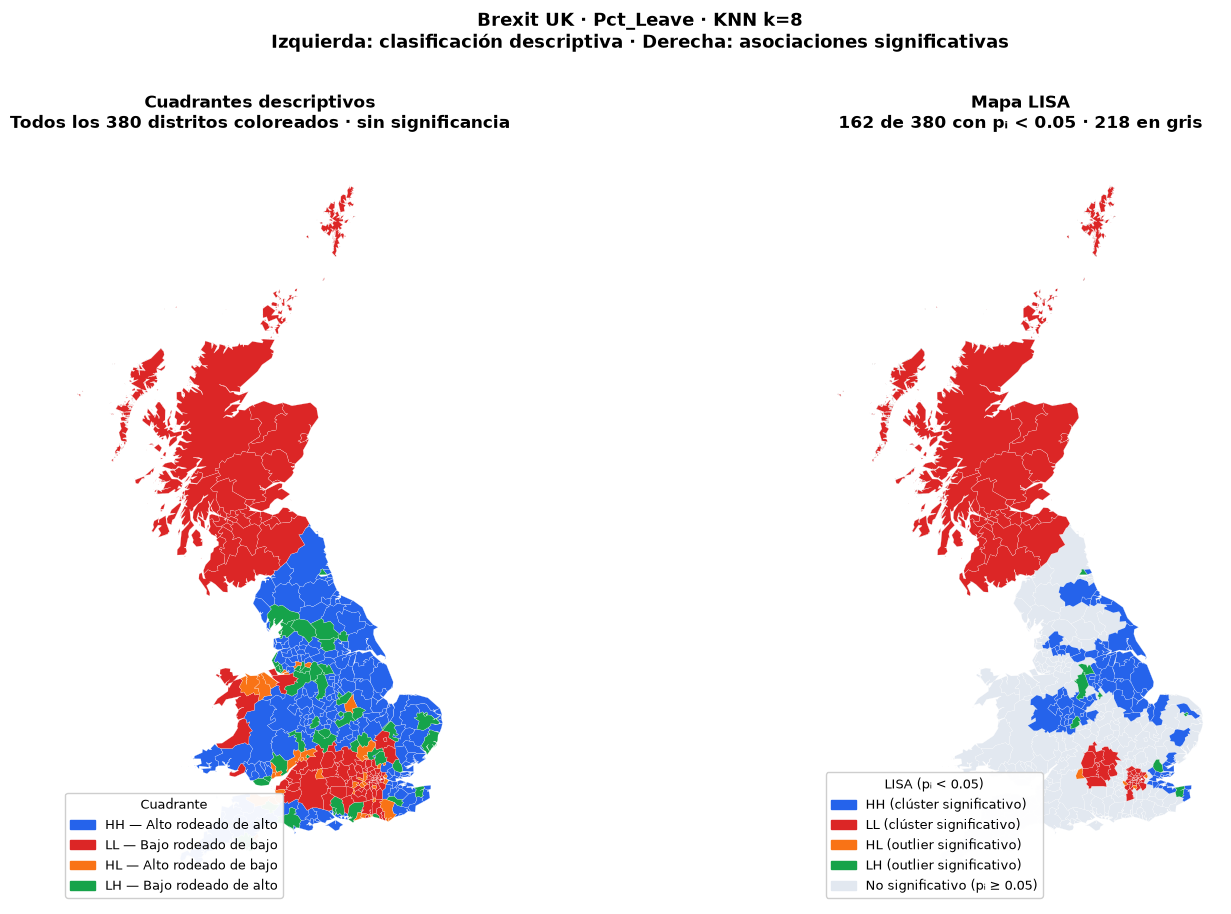

─── Brexit: descriptivo vs. LISA ────────────────────────────────────────
  Cuadrante  Descriptivo     LISA   Pasan a gris
  ────────────────────────────────────────────
  HH              183       77            106
  LL              113       73             40
  HL               34        4             30
  LH               50        8             42
  Total           380      162            218


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Cuadrantes descriptivos vs. LISA — Brexit UK
# ─────────────────────────────────────────────────────────────────────────────

# Diccionarios (autosuficientes — no dependen de la celda anterior)
col      = {1:'#2563EB', 2:'#16A34A', 3:'#DC2626', 4:'#F97316'}
col_lisa = {1:'#2563EB', 2:'#16A34A', 3:'#DC2626', 4:'#F97316', 0:'#E2E8F0'}
nom_desc = {1:'HH — Alto rodeado de alto', 2:'LH — Bajo rodeado de alto',
            3:'LL — Bajo rodeado de bajo', 4:'HL — Alto rodeado de bajo'}
nom_lisa = {1:'HH (clúster significativo)', 2:'LH (outlier significativo)',
            3:'LL (clúster significativo)', 4:'HL (outlier significativo)',
            0:'No significativo (pᵢ ≥ 0.05)'}

def cuadrante(zi, wzi):
    if   zi > 0 and wzi > 0: return 1
    elif zi < 0 and wzi < 0: return 3
    elif zi > 0 and wzi < 0: return 4
    else:                    return 2

y_brex  = db['Pct_Leave'].values
z_brex  = (y_brex - y_brex.mean()) / y_brex.std()
Wz_brex = weights.lag_spatial(w_brex, z_brex)

db['cuad_desc'] = [cuadrante(z, wz) for z, wz in zip(z_brex, Wz_brex)]

ml_brex  = esda.Moran_Local(y_brex, w_brex, permutations=999)
sig_brex = ml_brex.p_sim < 0.05
db['lisa_sig'] = ml_brex.q * sig_brex.astype(int)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# ── Panel izquierdo: cuadrantes descriptivos ─────────────────────────────────
ax1 = axes[0]
for q, color in col.items():
    db[db['cuad_desc'] == q].plot(
        ax=ax1, color=color, edgecolor='white', linewidth=0.15, zorder=2)
ax1.legend(handles=[mpatches.Patch(color=col[q], label=nom_desc[q])
                    for q in [1,3,4,2]],
           loc='lower left', fontsize=9,
           title='Cuadrante', title_fontsize=9, framealpha=0.95)
ax1.set_title(f'Cuadrantes descriptivos\n'
              f'Todos los {len(db)} distritos coloreados · sin significancia',
              fontsize=12, fontweight='bold')
ax1.set_axis_off()

# ── Panel derecho: mapa LISA ──────────────────────────────────────────────────
ax2 = axes[1]
db.plot(ax=ax2, color='#E2E8F0', edgecolor='white', linewidth=0.15, zorder=1)
for q, color in col_lisa.items():
    if q == 0: continue
    mask = db['lisa_sig'] == q
    if mask.sum() > 0:
        db[mask].plot(ax=ax2, color=color,
                      edgecolor='white', linewidth=0.15, zorder=3)
ax2.legend(handles=[mpatches.Patch(color=col_lisa[q], label=nom_lisa[q])
                    for q in [1,3,4,2,0]],
           loc='lower left', fontsize=9,
           title='LISA (pᵢ < 0.05)', title_fontsize=9, framealpha=0.95)
ax2.set_title(f'Mapa LISA\n'
              f'{sig_brex.sum()} de {len(db)} con pᵢ < 0.05 · '
              f'{len(db)-sig_brex.sum()} en gris',
              fontsize=12, fontweight='bold')
ax2.set_axis_off()

plt.suptitle('Brexit UK · Pct_Leave · KNN k=8\n'
             'Izquierda: clasificación descriptiva · Derecha: asociaciones significativas',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/s07_brex_desc_vs_lisa.png', dpi=150, bbox_inches='tight')
plt.show()

print('─── Brexit: descriptivo vs. LISA ────────────────────────────────────────')
print(f'  {"Cuadrante":<6} {"Descriptivo":>12} {"LISA":>8} {"Pasan a gris":>14}')
print('  ' + '─'*44)
for q, nombre in [(1,'HH'),(3,'LL'),(4,'HL'),(2,'LH')]:
    nd = (db['cuad_desc'] == q).sum()
    nl = (db['lisa_sig']  == q).sum()
    print(f'  {nombre:<6} {nd:>12} {nl:>8} {nd-nl:>14}')
print(f'  {"Total":<6} {len(db):>12} {sig_brex.sum():>8} '
      f'{len(db)-sig_brex.sum():>14}')

---
## Parte C — Moran Global vs. LISA

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA C1 — Moran Global vs. LISA: la comparación que cierra el argumento
# ─────────────────────────────────────────────────────────────────────────────
mi_cic  = esda.Moran(y_cic,  w_cic,  permutations=999)
mi_brex = esda.Moran(y_brex, w_brex, permutations=999)

print('═══════════════════════════════════════════════════════════════════════')
print('  MORAN GLOBAL vs. LISA')
print('═══════════════════════════════════════════════════════════════════════')
print()
for nombre, mi, ml, sig, n in [
    ('Ciclistas Medellín', mi_cic,  ml_cic,  sig_mask, len(ciclistas)),
    ('Brexit UK',          mi_brex, ml_brex, sig_brex, len(db))]:
    print(f'─── {nombre} ──────────────────────────────────────────────')
    print(f'  Moran Global  I = {mi.I:.4f}  p = {mi.p_sim:.4f}')
    print(f'  LISA  {sig.sum()} de {n} unidades con pᵢ < 0.05')
    for q, nom in nombres_q.items():
        s = ((ml.q==q)&sig).sum()
        if s>0: print(f'    {nom}: {s}')
    print()

print('─── Lo que cada análisis responde ───────────────────────────────────────')
print()
print('  Moran Global → ¿EXISTE el patrón espacial?')
print('    "I = 0.31, p < 0.001 — hay clustering en la distancia de viaje."')
print()
print('  LISA         → ¿DÓNDE está el patrón?')
print('    "234 ciclistas tienen asociaciones significativas con su entorno.')
print('     71 HH en el norte/noroccidente · 114 LL en el suroriente."')
print()
print('  No son rivales. El Moran Global motiva el LISA.')
print('  El LISA localiza lo que el Global detectó.')

═══════════════════════════════════════════════════════════════════════
  MORAN GLOBAL vs. LISA
═══════════════════════════════════════════════════════════════════════

─── Ciclistas Medellín ──────────────────────────────────────────────
  Moran Global  I = 0.3122  p = 0.0010
  LISA  241 de 810 unidades con pᵢ < 0.05
    HH: 76
    LH: 24
    LL: 113
    HL: 28

─── Brexit UK ──────────────────────────────────────────────
  Moran Global  I = 0.6455  p = 0.0010
  LISA  162 de 380 unidades con pᵢ < 0.05
    HH: 77
    LH: 8
    LL: 73
    HL: 4

─── Lo que cada análisis responde ───────────────────────────────────────

  Moran Global → ¿EXISTE el patrón espacial?
    "I = 0.31, p < 0.001 — hay clustering en la distancia de viaje."

  LISA         → ¿DÓNDE está el patrón?
    "234 ciclistas tienen asociaciones significativas con su entorno.
     71 HH en el norte/noroccidente · 114 LL en el suroriente."

  No son rivales. El Moran Global motiva el LISA.
  El LISA localiza lo que el Globa

---
## Parte D — Datos propios del equipo

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA D1 — LISA datos propios
# Modificar las 3 líneas de configuración
# ─────────────────────────────────────────────────────────────────────────────
RUTA_DATOS    = 'data/mi_proyecto.gpkg'
VARIABLE_Y    = 'mi_variable_y'
NOMBRE_EQUIPO = 'Equipo X'

try:
    from libpysal.weights import Queen
    gdf = gpd.read_file(RUTA_DATOS)
    if gdf.crs is None or gdf.crs.is_geographic:
        gdf = gdf.to_crs('EPSG:3116')
    gdf[VARIABLE_Y] = pd.to_numeric(gdf[VARIABLE_Y], errors='coerce')
    gdf = gdf.dropna(subset=[VARIABLE_Y])

    geom = gdf.geometry.geom_type.unique()[0]
    w_p  = (Queen.from_dataframe(gdf) if geom in ['Polygon','MultiPolygon']
            else KNN.from_dataframe(gdf, k=5))
    w_p.transform = 'r'

    y_p  = gdf[VARIABLE_Y].values
    mi_p = esda.Moran(y_p, w_p, permutations=999)
    ml_p = esda.Moran_Local(y_p, w_p, permutations=999)
    sig_p = ml_p.p_sim < 0.05
    gdf['lisa_sig'] = ml_p.q * sig_p.astype(int)

    print(f'─── {NOMBRE_EQUIPO} ─────────────────────────────────────────────')
    print(f'  Moran Global  I = {mi_p.I:.4f}  p = {mi_p.p_sim:.4f}')
    print(f'  LISA  {sig_p.sum()} de {len(gdf)} unidades con pᵢ < 0.05')
    for q, nombre in nombres_q.items():
        n = ((ml_p.q==q)&sig_p).sum()
        if n>0: print(f'    {nombre}: {n}')
    print()
    print('─── Verificación hipótesis Hito 2 ───────────────────────────────────')
    print('  ¿El mapa LISA confirma la hipótesis que formularon?')
    print('  "Sospechamos que el clustering está en [zona]..."')
    print('  ¿Se confirmó? ¿Se rechazó? ¿Se refinó?')

    fig, ax = plt.subplots(figsize=(10, 9))
    gdf.plot(ax=ax, color='#E2E8F0', edgecolor='white', linewidth=0.2, zorder=1)
    for q, color in col_lisa.items():
        if q==0: continue
        mask = gdf['lisa_sig']==q
        if mask.sum()>0:
            gdf[mask].plot(ax=ax, color=color, edgecolor='white',
                           linewidth=0.2, markersize=6, zorder=3)
    ax.legend(handles=[mpatches.Patch(color=col_lisa[q],label=nom_lisa[q]) for q in [1,3,4,2,0]],
              loc='lower right', fontsize=9)
    ax.set_title(f'Mapa LISA — {NOMBRE_EQUIPO}\n'
                 f'{VARIABLE_Y} · I = {mi_p.I:.4f} · {sig_p.sum()} unidades sig.',
                 fontsize=12, fontweight='bold')
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(f'outputs/s07_D_{NOMBRE_EQUIPO.replace(" ","_")}_lisa.png',
                dpi=150, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f'⚠ {e}')
    print('  Actualiza RUTA_DATOS y VARIABLE_Y.')

⚠ data/mi_proyecto.gpkg: No such file or directory
  Actualiza RUTA_DATOS y VARIABLE_Y.


---
## Resumen de la secuencia completa

```
Clase 6                              Clase 7
────────────────────────────         ──────────────────────────────────────
zᵢ y Wzᵢ calculados                 Iᵢ = zᵢ × Wzᵢ  ← multiplicación
Moran Scatterplot                    Prueba permutacional local (999x)
Cuadrantes HH/LL/HL/LH               pᵢ por cada zona
  (descriptivo — sin pᵢ)             Filtro pᵢ < 0.05
Mapa de cuadrantes                   Mapa LISA
  (todos coloreados)                   (solo los significativos · resto gris)
```

> *El LISA responde dónde está el patrón. La siguiente pregunta es por qué.*
> *Eso abre la puerta a X y WX — los modelos de Juan Carlos Duque.*

---
*CM0866 · Juan Pablo Ospina Zapata · EAFIT 2026*